In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging
import os

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Linux
# fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
# fontprop = fm.FontProperties(fname=fontpath, size=12)
# plt.rcParams["font.family"] = fontprop.get_name()

# 맥 전용 나눔고딕 설정
# 경로 파일 대신 시스템에 설치된 폰트 이름(family)으로 넣기
fontprop = fm.FontProperties(family='NanumGothic', size=12)
plt.rcParams['axes.unicode_minus'] = False

print(f"설정된 폰트: {fontprop.get_name()}")



설정된 폰트: NanumGothic


In [2]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')

device = get_device()
print(f'Using device: {device}')
print(torch.__version__)

Using device: mps
2.3.0


In [3]:
import os
import urllib.request
import zipfile


# dataset_dir = os.path.join(os.path.expanduser("/content/datasets"), "spa-eng")

dataset_dir = "./datasets/spa-eng"
os.makedirs(dataset_dir, exist_ok=True)
zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


In [4]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [5]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

In [61]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


In [8]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [62]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3


# 살재 토큰 ID 정의

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [63]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [64]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [65]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


In [67]:
# 1: 문장 시작 (BOS)
# 425, 112, 89, 15: how are you ? (실제 내용)
# 2: 문장 끝 (EOS)

enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 28, 10, 52, 401, 15, 2]

In [68]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

In [69]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. 원본 텍스트 가져오기
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        # 2. 토크나이저를 사용해 '글자' -> '숫자 ID(리스트)' 로 변환
        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        # 3. 최대 길이 제한을 적용합니다.
        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids)) 
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))


        # torch.tensor(src_ids):
        # 모델의 인코더(Encoder) 파트에 들어갈 영어 문제지입니다.
        # 예: [425, 112, 89, 15, 0, ...] ("how are you?")
        
        # torch.tensor(trg_input):
        # 모델의 디코더(Decoder) 파트에 들어갈 스페인어 힌트입니다.
        # 맨 앞에 "시작(BOS)" 기호가 붙어있어, 디코더가 첫 단어를 내뱉게끔 시동을 걸어줍니다.
        # 예: [1, 5, 20, 2, 0, ...] (" Te amo")
        # torch.tensor(trg_label):
        # 디코더가 trg_input을 보고 예측한 결과와 비교해 채점할 진짜 정답지입니다.
        # 힌트보다 한 칸 앞서 있고, 마지막에 "끝(EOS)" 기호를 맞춰야 합니다.
        # 예: [5, 20, 2, 0, 0, ...] ("Te amo ")

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [12]:
# train_ratio = 0.8: 전체 데이터 중 80%는 공부(학습)하는 데 쓰고, 20%는 시험(검증) 보는 데 쓰겠다는 뜻입니다. 
# (주석의 70%는 이전 작성자의 오타인 듯합니다!)
# MAX_LEN = 30: 한 문장의 최대 길이를 30 단어(토큰)로 짤라 맞추겠다는 뜻입니다. 
# 앞서 우리가 살펴본 [:self.max_len]과 빈칸 채우기(self.pad_id)의 기준이 되는 숫자입니다.
# BATCH_SIZE = 64: 문제집을 한 번에 64문제씩 풀고 채점하겠다는 뜻입니다. 
# 너무 한 번에 많이 풀면 컴퓨터 메모리가 터지고, 너무 적게 풀면 학습이 오래 걸립니다.

train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64


# train_data = df.sample(...): 전체 데이터프레임(df)에서 랜덤하게 80%(frac=0.8)를 쏙쏙 뽑아내어 학습용 문제집으로 만듭니다. 
# (random_state=42는 항상 똑같이 랜덤하게 뽑히도록 고정번호를 주는 겁니다.)
# valid_data = df.drop(...): 방금 뽑혀나간 학습용 80%의 자리(index)를 쓰레기통에 버려버리면(drop), 
# 나머지 20%만 남겠죠? 이것을 시험용(검증) 문제집으로 씁니다.

train_data = df.sample(frac=train_ratio, random_state=42)  # 70% 훈련 데이터
valid_data = df.drop(train_data.index)

# 위에서 랜덤하게 데이터를 뽑았기 때문에, 데이터의 행 번호(인덱스)가 [42, 11, 2095, ...]처럼 아주 뒤죽박죽이 되어 있습니다.
# 이걸 다시 예쁘게 [0, 1, 2, 3...]으로 번호표를 새로 고쳐 다는 과정입니다. 나중에 순서대로 꺼내 쓰기 편하게요.
train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validataion_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validataion_data, batch_size=BATCH_SIZE, shuffle=False)

for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
 # nn.Linear       
 # Input: (*, in_features)
 # Output: (*, out_features)
 # "앞에 있는 batch_size와 src_len은 정보의 '덩어리 개수'일 뿐이야. 나는 이 덩어리들을 건드리지 않고, 
 # 가장 마지막 차원에 있는 hidden_dim 개의 숫자들만 쏙 빼서 내 가중치 행렬과 곱한 다음, 
 # out_features 크비의 숫자로 바꿔서 그 자리에 다시 쏙 넣어줄게."       

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)
        src_len = encoder_outputs.shape[0]

# 예 (2, 3) ➡️ (2, 1, 3)
#      [
#        [ [1, 2, 3] ],   # 0번 배치: 덩어리 [1,2,3] 이 한 겹 더 싸임
#        [ [4, 5, 6] ]    # 1번 배치: 덩어리 [4,5,6] 이 한 겹 더 싸임
#      ]
#      (배치 개수, 1, 히든 차원)     
# [
  # 1번 문장의 방 안에서 [10, 20]이 3번 복사됨!
#   [ [10, 20], 
#     [10, 20], 
#     [10, 20] ], 
#   # 2번 문장의 방 안에서 [80, 90]이 3번 복사됨!
#   [ [80, 90], 
#     [80, 90], 
#     [80, 90] ]  
# ]


        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        # encoder_outputs (src_len, batch_size, hidden_dim) 
        # 파이토치에서 기본적으로 제공하는 nn.RNN, nn.GRU, nn.LSTM과 같은 순환 신경망 모듈을 만들 때는 batch_first라는 옵션이 있습니다.

        # 이 옵션의 기본값(Default)은 False입니다.
        # 파이토치 개발자들은 초창기부터 "순환 신경망(RNN)에서는 무엇보다 시간이 흘러가는 순서(Sequence/Length)가 제일 중요하니까, 제일 바깥쪽(0번째 축)에 시간(길이) 정보를 두자!" 라고 결정했습니다.     
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)
        #여기에 permute(1, 0, 2)를 적용하면 파이토치는 이렇게 해석합니다:
        #첫 번째 파라미터 1: "새로운 텐서의 0번째(첫 번째) 자리에, 원래 텐서의 **1번 차원(batch_size)**을 가져와라!"
        #두 번째 파라미터 0: "새로운 텐서의 1번째(두 번째) 자리에, 원래 텐서의 **0번 차원(src_len)**을 가져와라!"
        #세 번째 파라미터 2: "새로운 텐서의 2번째(세 번째) 자리에, 원래 텐서의 **2번 차원(hidden_dim)**을 가져와라!"
       
       
       # 그냥 두 정보를 더해서(섞어서) 짬뽕 벡터(energy)를 만듦
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)
     

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [85]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
    # tensor([
    # # 첫 번째 배치(문장 1)에 대한 어텐션 점수
    # [0.10,  0.80,  0.10], 
    # # 두 번째 배치(문장 2)에 대한 어텐션 점수
    # [0.05,  0.05,  0.90]  
    # ])
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [87]:
device = get_device()
input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [88]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [89]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [90]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)


In [91]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)



In [ ]:
# %%time

# EPOCHS = 10

# for epoch in range(EPOCHS):
#     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
#     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

In [95]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)



In [96]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 1488/1488 [02:45<00:00,  8.99it/s, loss=0.571]


Epoch 1/20, Train Loss: 0.5753, Validation Loss: 1.3754


Epoch 2: 100%|██████████| 1488/1488 [02:53<00:00,  8.59it/s, loss=0.251]


Epoch 2/20, Train Loss: 0.4690, Validation Loss: 1.4343


Epoch 3: 100%|██████████| 1488/1488 [02:48<00:00,  8.83it/s, loss=0.401]


...

Epoch 18/20, Train Loss: 0.2599, Validation Loss: 2.0809


Epoch 19: 100%|██████████| 1488/1488 [02:40<00:00,  9.26it/s, loss=0.48] 


Epoch 19/20, Train Loss: 0.2617, Validation Loss: 2.1100


Epoch 20: 100%|██████████| 1488/1488 [02:41<00:00,  9.23it/s, loss=0.199]


Epoch 20/20, Train Loss: 0.2636, Validation Loss: 2.1233
CPU times: user 51min 25s, sys: 11min 31s, total: 1h 2min 56s
Wall time: 59min 20s


In [97]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [98]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [99]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'm', 's', 'poder', 'o', 'hombre', 'de', 'toda', 's', 'al', 'mund', 'o', '.', '']


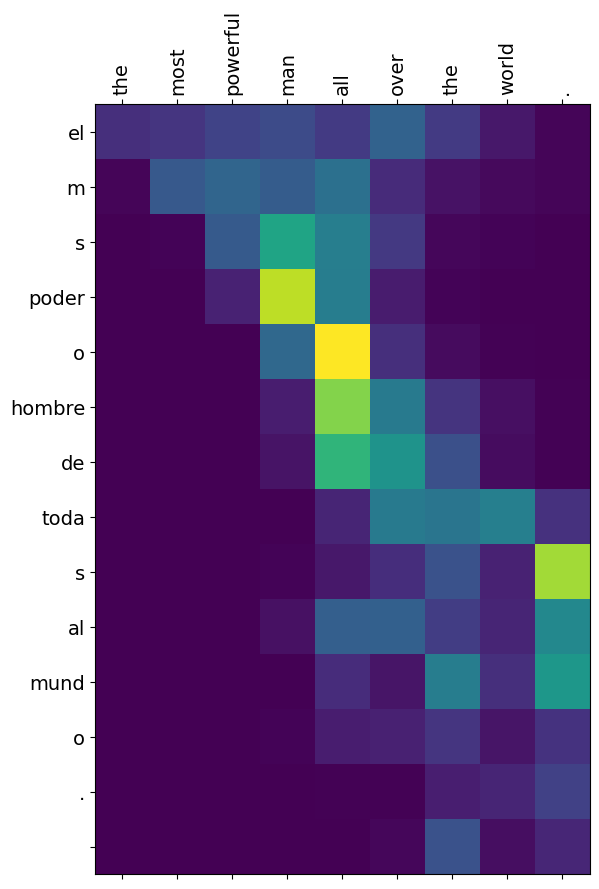

In [100]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'te', '?', '']


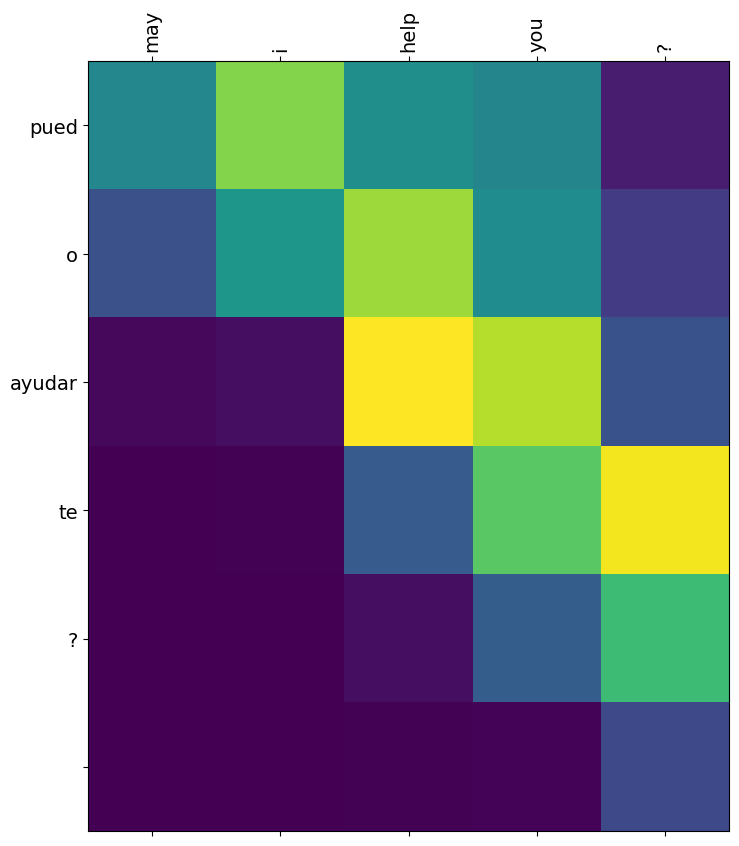

In [101]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['me', 'pued', 'o', 'tomar', 'caf', '?', '']


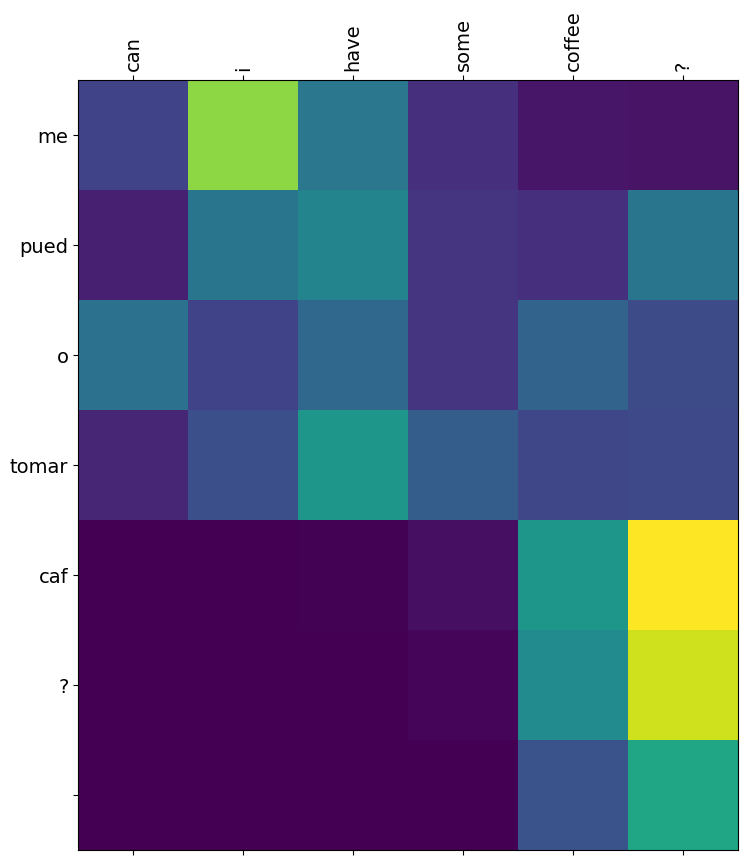

In [102]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)